<a href="https://colab.research.google.com/github/momo4201/AI-ML-projects/blob/main/(Naive_bayes_classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#model based classifier----based on population or spatial distribution
#instance based classifier---based on proximity(neighbourhood)
#feature map
#softmax
p(alpha/X)--- X= feature vector, P()----prior probability
x=[x1,x2,x3...]
i.i.d = Independent and Identically Distributed---- an assumption that we generally make . without this assumption u cannot calculate conditional probability
#theorem of total probability-----depends on past events. but the past events are independent of eachother. calculate probability of present event
argmax()
higher one
probability using bayes thrm, softmax, sigmoid
natural frequency--- the no. of times u see a words ----- normal distribution
cross entropy, log loss--- loss function in classification
precision-recall tradeoff

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
os.getcwd()

Mounted at /content/drive


'/content'

In [ ]:
os.getcwd()

'/content'

In [ ]:
import os

os.listdir('/content/drive/MyDrive')

In [ ]:
os.listdir('/content/drive/MyDrive/AI_ML_LAB')

['lifesat',
 'Pages_Dataset.xlsx',
 'Spam_Classifier-20260129T101127Z-3-001',
 'PIMA_Diabetes_Dataset.csv']

In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/AI_ML_LAB/PIMA_Diabetes_Dataset.csv',
    encoding='latin1',
    header=None
)

In [ ]:
df = df.drop(0).reset_index(drop=True)

In [ ]:
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

In [ ]:
df = df.apply(pd.to_numeric)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.head(5)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
import os
import io
import numpy
import pandas as pd
from pandas import DataFrame
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
faccuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.957471264367816
Precision: 0.5737704918032787
Recall   : 0.6481481481481481
F1 Score : 0.6086956521739131

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



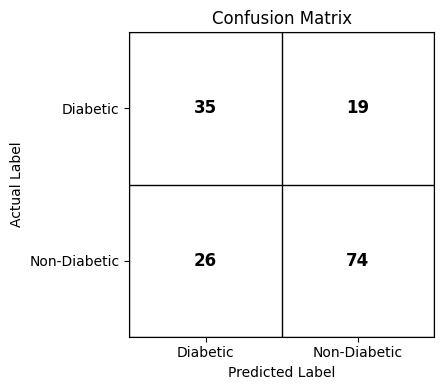

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix (0 = Non-Diabetic, 1 = Diabetic)
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

fig, ax = plt.subplots(figsize=(5, 4))

# Draw empty grid (no color, no shading)
ax.imshow(np.ones_like(cm), cmap='gray', vmin=0, vmax=1)

# Labels
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Diabetic', 'Non-Diabetic'])
ax.set_yticklabels(['Diabetic', 'Non-Diabetic'])

# Draw grid lines
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# Insert values
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

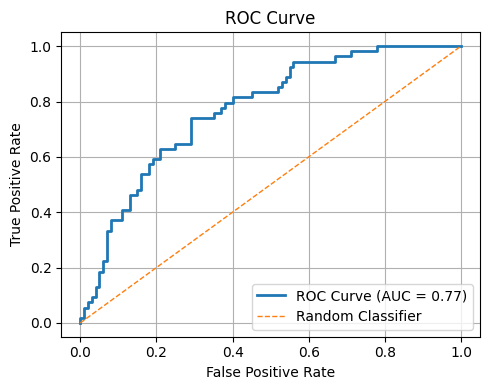

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -------------------------------
# Get probability scores
# -------------------------------
# Positive class = 1 (Diabetic)
y_scores = classifier.predict_proba(X_test)[:, 1]

# -------------------------------
# ROC computation
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# -------------------------------
# Plot ROC Curve
# -------------------------------
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, linestyle='-', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1,
         label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()